In [1]:
import os
%load_ext autoreload
%autoreload 2

In [2]:
# Cell 1: Imports (Make sure these are at the top of your notebook)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys

from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset

from training.trainer import Trainer, Config

In [3]:
print(os.getcwd())

C:\Users\dpark\repos\crytpo_DLOB\notebooks


In [4]:
os.chdir('..')  # only need this temporily to get the right paths, change as needed
print(os.getcwd())

C:\Users\dpark\repos\crytpo_DLOB


In [118]:
import yaml
with open("configs/test.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [73]:
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [119]:
config.num_files

In [166]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000071
Shape after label creation and NaN drop: (4817823, 44)
Label distribution:
label
1    0.464005
2    0.269410
0    0.266585
Name: proportion, dtype: float64


0

In [167]:
display(df_processed.shape)
df_processed.head()

(4817823, 44)

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,aq4,aq5,aq6,aq7,aq8,aq9,mid_price,spread,vol_imbalance_10,label
50,69880.250000,69879.437500,69879.343750,69879.328125,69879.312500,69878.257812,69876.460938,69876.453125,69872.820312,69872.812500,...,0.200000,0.094076,0.257191,0.046148,0.010000,0.056200,69880.250000,0.007812,0.380388,0
51,69869.750000,69868.703125,69866.609375,69866.312500,69865.843750,69863.671875,69863.242188,69862.820312,69861.937500,69860.710938,...,0.003437,0.000158,0.206922,0.044053,0.488620,0.010000,69869.750000,0.007812,0.406502,0
52,69857.226562,69857.218750,69857.210938,69857.179688,69855.382812,69854.320312,69853.062500,69852.843750,69852.617188,69851.679688,...,0.093890,0.026734,0.044646,0.044469,0.204451,0.549270,69859.171875,3.882812,0.051437,0
53,69857.226562,69857.218750,69857.210938,69857.179688,69855.382812,69854.320312,69853.062500,69852.843750,69852.617188,69851.679688,...,0.038398,0.093890,0.026734,0.044646,0.044469,0.204451,69859.164062,3.875000,0.380259,0
54,69857.226562,69857.218750,69857.210938,69857.179688,69855.382812,69854.320312,69853.062500,69852.843750,69852.617188,69851.679688,...,0.038398,0.093890,0.044469,0.204451,0.549270,0.044382,69859.148438,3.843750,0.038509,0


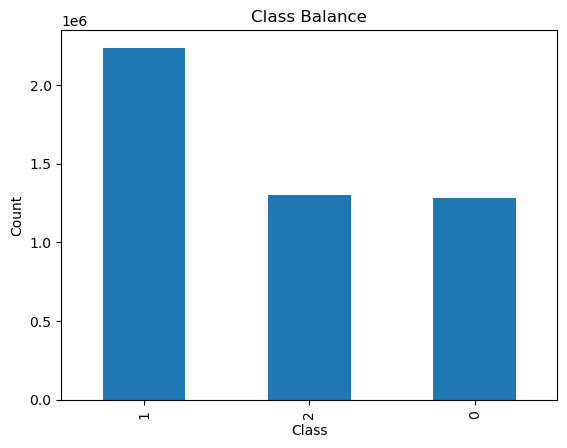

In [168]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [169]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372476, Val=722673, Test=722674


2837

In [172]:
train_df.dtypes.unique(), val_df.dtypes.unique(), test_df.dtypes.unique(),

(array([dtype('float32'), dtype('float64'), dtype('int64')], dtype=object),
 array([dtype('float32'), dtype('float64'), dtype('int64')], dtype=object),
 array([dtype('float32'), dtype('float64'), dtype('int64')], dtype=object))

In [173]:
train_df.head()

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,aq4,aq5,aq6,aq7,aq8,aq9,mid_price,spread,vol_imbalance_10,label
50,69880.250000,69879.437500,69879.343750,69879.328125,69879.312500,69878.257812,69876.460938,69876.453125,69872.820312,69872.812500,...,0.200000,0.094076,0.257191,0.046148,0.010000,0.056200,69880.250000,0.007812,0.380388,0
51,69869.750000,69868.703125,69866.609375,69866.312500,69865.843750,69863.671875,69863.242188,69862.820312,69861.937500,69860.710938,...,0.003437,0.000158,0.206922,0.044053,0.488620,0.010000,69869.750000,0.007812,0.406502,0
52,69857.226562,69857.218750,69857.210938,69857.179688,69855.382812,69854.320312,69853.062500,69852.843750,69852.617188,69851.679688,...,0.093890,0.026734,0.044646,0.044469,0.204451,0.549270,69859.171875,3.882812,0.051437,0
53,69857.226562,69857.218750,69857.210938,69857.179688,69855.382812,69854.320312,69853.062500,69852.843750,69852.617188,69851.679688,...,0.038398,0.093890,0.026734,0.044646,0.044469,0.204451,69859.164062,3.875000,0.380259,0
54,69857.226562,69857.218750,69857.210938,69857.179688,69855.382812,69854.320312,69853.062500,69852.843750,69852.617188,69851.679688,...,0.038398,0.093890,0.044469,0.204451,0.549270,0.044382,69859.148438,3.843750,0.038509,0


In [174]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()


Columns selected for scaling (43): ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9']...


C:\Users\dpark\repos\crytpo_DLOB\preprocessing\preprocessing.py:591: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.38577218 -0.39089587 -0.39700693 ...  2.03836048  2.03836048
  2.03836048]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  
C:\Users\dpark\repos\crytpo_DLOB\preprocessing\preprocessing.py:591: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.36934916 -0.37452966 -0.38007211 ...  2.02784787  2.02784787
  2.02784787]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  
C:\Users\dpark\repos\crytpo_DLOB\preprocessing\preprocessing.py:591: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.36857336 -0.37471888 -0.37925451 ...  2.02817803  2.02817803
  2.02817803]' has dtype incom

Normalization applied.


0

In [175]:
train_df_norm.head()

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,aq4,aq5,aq6,aq7,aq8,aq9,mid_price,spread,vol_imbalance_10,label
50,-0.385772,-0.369349,-0.368573,-0.368063,-0.367603,-0.362745,-0.363020,-0.353651,-0.354784,-0.353862,...,0.118759,-0.090547,-0.142578,-0.111765,-0.180246,-0.156775,-0.337643,0.357074,0.986878,0
51,-0.390896,-0.374530,-0.374719,-0.374344,-0.374104,-0.369774,-0.369390,-0.360197,-0.360009,-0.359671,...,-0.170537,-0.203195,-0.161195,-0.113840,0.382066,-0.213389,-0.342925,0.357074,1.043666,0
52,-0.397007,-0.380072,-0.379255,-0.378752,-0.379152,-0.374281,-0.374296,-0.364988,-0.364484,-0.364006,...,-0.037411,-0.171318,-0.221292,-0.113428,0.048206,0.447434,-0.348245,0.362875,0.271536,0
53,-0.397007,-0.380072,-0.379255,-0.378752,-0.379152,-0.374281,-0.374296,-0.364988,-0.364484,-0.364006,...,-0.119083,-0.090770,-0.227925,-0.113253,-0.139750,0.024892,-0.348249,0.362863,0.986598,0
54,-0.397007,-0.380072,-0.379255,-0.378752,-0.379152,-0.374281,-0.374296,-0.364988,-0.364484,-0.364006,...,-0.119083,-0.090770,-0.221357,0.045010,0.453321,-0.171256,-0.348257,0.362816,0.243423,0


In [176]:
config.sequence_length = 1

In [177]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float16).values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].astype(np.float16).values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].astype(np.float16).values

T = config.sequence_length
X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision=np.float16)
X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision=np.float16)
X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision=np.float16)

print("\nSequence Creation Complete:")
print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}, y_val_seq shape: {y_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()


Sequence Creation Complete:
X_train_seq shape: (3372475, 1, 43), y_train_seq shape: (3372475,)
X_val_seq shape: (722672, 1, 43), y_val_seq shape: (722672,)
X_test_seq shape: (722673, 1, 43), y_test_seq shape: (722673,)


0

In [178]:
# --- 5. Create Datasets & DataLoaders ---
train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
val_dataset = LOBSequenceDataset(X_val_seq, y_val_seq, device=device)
test_dataset = LOBSequenceDataset(X_test_seq, y_test_seq, device=device)

#train_loader = DataLoader(train_dataset, batch_size=config.train.batch_size, shuffle=True) # num_workers/pin_memory optional
#val_loader = DataLoader(val_dataset, batch_size=config.train.batch_size, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=config.train.batch_size, shuffle=False)
# gc.collect()

In [179]:
config.model.in_features = 43

In [183]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, device)


Datasets and DataLoaders created.
Number of training batches: 3294
Number of validation batches: 706
Number of testing batches: 706


In [181]:
trainer.device

'cuda'

In [ ]:
trainer.train()

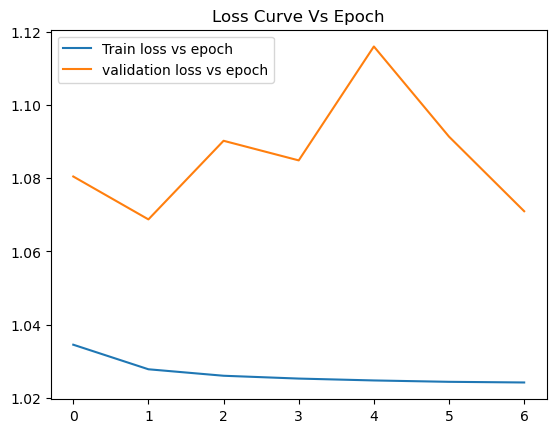

In [117]:
pd.Series(trainer.train_loss).plot(label="Train loss vs epoch")
pd.Series(trainer.val_loss).plot(label="validation loss vs epoch")
plt.title("Loss Curve Vs Epoch")
plt.legend()
plt.show()